# 할루시네이션 자가 검증 기능을 활용한 Self-RAG 챗봇 구현

실습1에서 만든 RAG 챗봇이 어떤 한계를 가질 수 있는지 먼저 확인하고, 이를 보완하는 Self-RAG 기법을 단계적으로 추가해보겠습니다.

## 0. 실습1의 RAG 챗봇 준비
각 조각(임베딩, 벡터스토어, 리트리버, 프롬프트, LCEL 체인)은 실습1에서 이미 하나씩 설명했으므로, 여기서는 완성된 RAG 체인을 한 셀에 그대로 재구현합니다.

In [1]:
import os

from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_chroma import Chroma
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_ollama import OllamaEmbeddings
from langchain_openai import ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter

load_dotenv()

# llm: 답변 생성 / embeddings: 문서 벡터화 (실습1과 동일한 역할 분리)
llm = ChatOpenAI(
    model=os.environ["MODEL_NAME"],
    base_url=os.environ["BASE_URL"],
    api_key=os.environ["OPENAI_API_KEY"],
    temperature=0,
)
embeddings = OllamaEmbeddings(model="qwen3-embedding:0.6b")

# 문서 로드 및 청킹 (실습1과 동일한 시장조사 PDF, 1500자 단위)
doc_path = "data/키오스크(무인정보단말기) 이용실태 조사.pdf"
docs = PyPDFLoader(doc_path).load()
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1500, chunk_overlap=200)
splited_docs = text_splitter.split_documents(docs)

# 벡터화 및 리트리버 생성
vectorstore = Chroma.from_documents(documents=splited_docs, embedding=embeddings)
db_retriever = vectorstore.as_retriever()

# 검색된 Document 리스트를 하나의 텍스트로 합치는 함수
def get_retrieved_text(docs):
    return "\n".join(doc.page_content for doc in docs)

# context, question 두 자리를 채워 프롬프트를 만듭니다.
prompt_with_context = ChatPromptTemplate.from_messages([
    ("system", "당신은 마케터 지원 챗봇입니다. 주어진 정보를 참고해 질문에 답하세요."),
    ("human", "정보: {context}.\n{question}."),
])

# 실습1에서 만든 최종 RAG 체인
def init_chain():
    return (
        {"context": db_retriever | get_retrieved_text, "question": RunnablePassthrough()}
        | prompt_with_context
        | llm
        | StrOutputParser()
    )

qa_chain = init_chain()
print("[준비 완료] qa_chain이 준비되었습니다.")

/var/folders/px/v7_qzrl907d919ql0sn3f74r0000gn/T/ipykernel_32932/3259410823.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


[준비 완료] qa_chain이 준비되었습니다.


## 1. 검색 문서 연관성 평가
---
`db_retriever`는 질문과 "가장 비슷한" 문서를 항상 몇 개 반환합니다. 문제는 진짜 관련 있는 문서가 하나도 없어도 마찬가지라는 점입니다. 먼저 이 한계를 직접 확인해봅시다.

In [2]:
# PDF(키오스크 이용실태 조사)와 전혀 무관한 질문을 던져봅니다.
off_topic_question = "파이썬에서 리스트를 정렬하는 방법을 알려줘"

retrieved_docs = db_retriever.invoke(off_topic_question)
print(f"검색된 문서 수: {len(retrieved_docs)}")
print(f"첫 번째 문서 미리보기:\n{retrieved_docs[0].page_content[:150]}")

print("\n[qa_chain 답변]")
print(qa_chain.invoke(off_topic_question))

검색된 문서 수: 4
첫 번째 문서 미리보기:
키오스크(무인정보단말기)이용 실태조사
33 시장조사국 시장감시팀
ㅇ (④선택 목록 계속 보여주기)선택한 상품‧
서비스의 목록을 결제 전까지 계속 아래에 띄워주는 기능은 모든 연령대가 84%이상 선호[표5-3-4] ‘선택 목록 계속 보여주기’ 기능 편의성(N=500)(단

[qa_chain 답변]
파이썬에서 리스트를 정렬하는 방법은 여러 가지가 있습니다. 가장 일반적인 방법은 `sort()` 메서드와 `sorted()` 함수를 사용하는 것입니다.

1. **`sort()` 메서드**: 이 메서드는 리스트 객체에 직접 적용되며, 리스트를 정렬하고 반환값은 없습니다. 원본 리스트가 변경됩니다.

```python
# 예시
my_list = [5, 2, 9, 1, 5, 6]
my_list.sort()  # 리스트를 오름차순으로 정렬
print(my_list)  # 출력: [1, 2, 5, 5, 6, 9]
```

2. **`sorted()` 함수**: 이 함수는 정렬할 리스트를 인자로 받아 새로운 정렬된 리스트를 반환합니다. 원본 리스트는 변경되지 않습니다.

```python
# 예시
my_list = [5, 2, 9, 1, 5, 6]
sorted_list = sorted(my_list)  # 새로운 정렬된 리스트 생성
print(sorted_list)  # 출력: [1, 2, 5, 5, 6, 9]
print(my_list)  # 원본 리스트는 변경되지 않음: [5, 2, 9, 1, 5, 6]
```

3. **내림차순 정렬**: 두 방법 모두 `reverse=True` 인자를 사용하여 내림차순으로 정렬할 수 있습니다.

```python
# sort() 메서드로 내림차순 정렬
my_list = [5, 2, 9, 1, 5, 6]
my_list.sort(reverse=True)
print(my_list)  # 출력: [9, 6, 5, 5, 2, 1]

# sorted() 함수로 내림차순 정렬
my_list = [5, 2,

질문과 전혀 관련 없는 내용인데도 `db_retriever`는 어떻게든 문서를 반환하고, `qa_chain`은 그 문서를 참고해 답하려고 합니다. 검색된 문서가 실제로 질문과 관련 있는지 판단하는 단계가 없기 때문입니다.

### 해결: `is_data_relevant`
검색된 문서와 질문의 연관성을 LLM에게 판단시켜, 관련 없으면 그 문서를 사용하지 않도록 만듭니다.

판단 결과를 코드에서 다루기 쉽도록, JSON 형식으로만 답하는 `route_llm`을 추가로 만듭니다. `llm`과 같은 모델이지만 출력 형식만 다릅니다.

In [3]:
from langchain_core.output_parsers import JsonOutputParser

# route_llm: llm과 동일한 모델이지만, JSON 형식으로만 답하도록 강제합니다. (연관성/할루시네이션 등 판단에 사용)
route_llm = llm.bind(response_format={"type": "json_object"})

In [4]:
# 검색된 문서(data)가 질문(question)과 실제로 관련 있는지 LLM에게 판단시킵니다.
def is_data_relevant(question: str, data: str) -> dict:
    system_message = """당신은 검색된 문서와 사용자의 질문의 연관성을 평가하는 평가자입니다.
다음은 검색된 문서입니다: \n{data}\n.
문서와 사용자가 입력할 질문이 연관이 있다면 true, 그렇지 않다면 false를 선택하세요.
답변은 'relevant' key(boolean) 하나만 있는 JSON으로 답변하고, 다른 텍스트나 설명을 생성하지 마세요."""

    relevant_judge_prompt = ChatPromptTemplate.from_messages([
        ("system", system_message),
        ("human", "{question}"),
    ])
    router_chain = relevant_judge_prompt | route_llm | JsonOutputParser()
    return router_chain.invoke({"question": question, "data": data})

# 방금 확인한 무관한 문서로 다시 판별해봅니다.
retrieved_text = get_retrieved_text(retrieved_docs)
print(f"[is_data_relevant 결과] {is_data_relevant(off_topic_question, retrieved_text)}")

[is_data_relevant 결과] {'relevant': False}


이제 `qa_chain`을 연관성 평가와 결합해, 관련 없는 문서는 사용하지 않고 곧바로 일반 답변으로 넘어가도록 만들어봅시다.

In [5]:
# 검색 -> 연관성 평가 -> (관련 있으면 RAG 답변 / 없으면 일반 답변)으로 이어지는 흐름을 함수로 만듭니다.
def answer_with_relevance_check(question: str) -> str:
    docs = db_retriever.invoke(question)
    context = get_retrieved_text(docs)

    if is_data_relevant(question, context)["relevant"]:
        print("[관련성 평가] 관련 있음 → 검색된 문서를 참고해 답변합니다.")
        return qa_chain.invoke(question)
    else:
        print("[관련성 평가] 관련 없음 → 검색 없이 LLM의 지식으로만 답변합니다.")
        return llm.invoke(question).content

In [6]:
print("[무관한 질문]")
print(answer_with_relevance_check("파이썬에서 리스트를 정렬하는 방법을 알려줘"))

print("\n[관련 있는 질문]")
print(answer_with_relevance_check("키오스크 이용률이 연령대별로 어떻게 달라?"))

[무관한 질문]
[관련성 평가] 관련 없음 → 검색 없이 LLM의 지식으로만 답변합니다.
파이썬에서 리스트를 정렬하는 방법은 여러 가지가 있습니다. 가장 일반적인 방법은 `sort()` 메서드와 `sorted()` 함수를 사용하는 것입니다.

### 1. `sort()` 메서드
`sort()` 메서드는 리스트 객체의 메서드로, 리스트를 직접 정렬합니다. 이 메서드는 리스트를 오름차순으로 정렬하며, 기본적으로 원본 리스트를 변경합니다.

```python
# 예제
my_list = [5, 2, 9, 1, 5, 6]
my_list.sort()
print(my_list)  # 출력: [1, 2, 5, 5, 6, 9]
```

내림차순으로 정렬하고 싶다면 `reverse=True` 인자를 사용할 수 있습니다.

```python
my_list.sort(reverse=True)
print(my_list)  # 출력: [9, 6, 5, 5, 2, 1]
```

### 2. `sorted()` 함수
`sorted()` 함수는 리스트를 정렬하여 새로운 리스트를 반환합니다. 원본 리스트는 변경되지 않습니다.

```python
# 예제
my_list = [5, 2, 9, 1, 5, 6]
sorted_list = sorted(my_list)
print(sorted_list)  # 출력: [1, 2, 5, 5, 6, 9]
print(my_list)      # 원본 리스트는 변경되지 않음
```

내림차순으로 정렬할 때도 `reverse=True` 인자를 사용할 수 있습니다.

```python
sorted_list_desc = sorted(my_list, reverse=True)
print(sorted_list_desc)  # 출력: [9, 6, 5, 5, 2, 1]
```

### 3. 사용자 정의 정렬
`sort()`와 `sorted()` 모두 `key` 인자를 사용하여 사용자 정의 정렬을 할 수 있습니다. 예를 들어, 문자열 리스트를 길이에 따라 정렬할 수 있습니다.

`

## 2. 답변 평가
---
검색된 문서가 질문과 관련 있다고 판단되어도(1번), 그 문서를 실제로 참고해서 제대로 답했는지는 다른 문제입니다. 먼저 이 한계를 확인해봅시다.

In [7]:
# 파이썬 공식 문서 일부 (RAG 없이도 LLM이 스스로 답할 수 있는 주제입니다)
relevant_document = "math.gcd(*integers): 지정된 정수 인자의 최대 공약수를 반환합니다. 인자 중 하나가 0이 아니면, 반환된 값은 모든 인자를 나누는 가장 큰 양의 정수입니다. 모든 인자가 0이면, 반환 값은 0입니다. 인자가 없는 gcd()는 0을 반환합니다."
irrelevant_document = "re.search(pattern, string, flags=0): string을 통해 스캔하여 정규식 pattern이 일치하는 첫 번째 위치를 찾고, 대응하는 일치 객체를 반환합니다."
question = "파이썬에서 공약수를 계산하는 방법을 알려주세요."

# 간단한 질의응답 체인을 만들어, 관련 있는 문서/없는 문서를 각각 증강해봅니다.
temp_prompt = ChatPromptTemplate.from_messages([
    ("system", "사용자가 입력하는 정보를 바탕으로 질문에 답하세요."),
    ("human", "정보: {data}.\n{question}."),
])
temp_chain = temp_prompt | llm | StrOutputParser()

relevant_answer = temp_chain.invoke({"data": relevant_document, "question": question})
irrelevant_answer = temp_chain.invoke({"data": irrelevant_document, "question": question})

print("[relevant_document로 답변]\n", relevant_answer)
print("\n[irrelevant_document로 답변]\n", irrelevant_answer)

[relevant_document로 답변]
 파이썬에서 최대 공약수(GCD)를 계산하는 방법은 `math` 모듈의 `gcd` 함수를 사용하는 것입니다. 이 함수는 두 개의 정수를 인자로 받아 그들의 최대 공약수를 반환합니다. 여러 개의 정수에 대한 최대 공약수를 계산하려면 `math.gcd`와 `functools.reduce`를 함께 사용할 수 있습니다.

다음은 파이썬에서 최대 공약수를 계산하는 방법에 대한 예제입니다:

```python
import math
from functools import reduce

# 두 개의 정수에 대한 최대 공약수 계산
a = 48
b = 18
gcd_ab = math.gcd(a, b)
print(f"{a}와 {b}의 최대 공약수는 {gcd_ab}입니다.")

# 여러 개의 정수에 대한 최대 공약수 계산
numbers = [48, 18, 30]
gcd_all = reduce(math.gcd, numbers)
print(f"{numbers}의 최대 공약수는 {gcd_all}입니다.")
```

위 코드에서:
- `math.gcd(a, b)`는 두 정수 `a`와 `b`의 최대 공약수를 계산합니다.
- `reduce(math.gcd, numbers)`는 리스트 `numbers`에 있는 모든 정수의 최대 공약수를 계산합니다.

이렇게 하면 원하는 정수들의 최대 공약수를 쉽게 구할 수 있습니다.

[irrelevant_document로 답변]
 파이썬에서 두 수의 공약수를 계산하는 방법은 여러 가지가 있지만, 가장 일반적인 방법은 유클리드 호제법을 사용하는 것입니다. 아래는 두 수의 공약수를 계산하는 예제 코드입니다.

```python
def gcd(a, b):
    while b:
        a, b = b, a % b
    return a

# 사용 예시
num1 = 48
num2 = 18
result = gcd(num1, num2)
print(f"{num1}와 {num2}의 공약수는 {result}입니다.")
```


증강한 문서와 무관하게, LLM이 자체적으로 학습한 지식으로 둘 다 올바른 답을 내놓습니다. 즉 검색 문서가 실제로 쓰였는지는 답변만 보고 알 수 없습니다.

### 해결: `is_answer_supportive`, `is_answer_useful`
답변이 질문에 대한 해답인지(`supportive`), 사용자에게 유용한지(`useful`)를 LLM에게 따로 판단시킵니다.

In [8]:
def is_answer_supportive(question: str, generation: str) -> dict:
    system_message = "당신은 AI의 답변이 사용자의 질문에 대한 해답인지 평가하는 평가자입니다."
    user_message = """사용자의 질문: {question}
AI의 답변: {generation}
AI의 답변이 사용자의 질문에 대한 해답이면 true, 아니라면 false를 선택하세요.
'answer' key(boolean) 하나만 있는 JSON 형식으로 답변하고, 다른 텍스트나 설명을 생성하지 마세요."""

    prompt = ChatPromptTemplate.from_messages([("system", system_message), ("human", user_message)])
    chain = prompt | route_llm | JsonOutputParser()
    return chain.invoke({"question": question, "generation": generation})


def is_answer_useful(question: str, generation: str) -> dict:
    system_message = "당신은 AI의 답변이 사용자에게 유용한지 평가하는 평가자입니다."
    user_message = """사용자의 질문: {question}
AI의 답변: {generation}
AI의 답변이 사용자에게 유용하다면 true, 아니라면 false를 선택하세요.
'useful' key(boolean) 하나만 있는 JSON 형식으로 답변하고, 다른 텍스트나 설명을 생성하지 마세요."""

    prompt = ChatPromptTemplate.from_messages([("system", system_message), ("human", user_message)])
    chain = prompt | route_llm | JsonOutputParser()
    return chain.invoke({"question": question, "generation": generation})


# 완전히 무관한(부정확한) 답변도 하나 만들어 비교해봅니다.
true_irrelevant_answer = "re.search를 통해 string을 통해 스캔하여 정규식 pattern이 일치하는 첫 번째 위치를 찾고, 대응하는 일치 객체를 반환할 수 있습니다."

print("[is_answer_supportive]")
print("relevant_answer:", is_answer_supportive(question, relevant_answer))
print("irrelevant_answer:", is_answer_supportive(question, irrelevant_answer))
print("true_irrelevant_answer:", is_answer_supportive(question, true_irrelevant_answer))

print("\n[is_answer_useful]")
print("relevant_answer:", is_answer_useful(question, relevant_answer))
print("irrelevant_answer:", is_answer_useful(question, irrelevant_answer))
print("true_irrelevant_answer:", is_answer_useful(question, true_irrelevant_answer))

[is_answer_supportive]
relevant_answer: {'answer': True}
irrelevant_answer: {'answer': True}
true_irrelevant_answer: {'answer': False}

[is_answer_useful]
relevant_answer: {'useful': True}
irrelevant_answer: {'useful': True}
true_irrelevant_answer: {'useful': False}


제대로 답한 앞의 두 경우는 `True`, 완전히 무관한 마지막 경우만 `False`로 잘 걸러냅니다. 이제 이 평가를 실제 챗봇 흐름에 결합해봅시다.

In [9]:
def answer_with_quality_check(question: str) -> str:
    context_answer = answer_with_relevance_check(question)
    supportive = is_answer_supportive(question, context_answer)["answer"]
    useful = is_answer_useful(question, context_answer)["useful"]
    print(f"[답변 평가] 지지: {supportive}, 유용성: {useful}")

    if supportive and useful:
        return context_answer
    print("[답변 평가] 기준 미달 → LLM 지식으로 다시 답변합니다.")
    return llm.invoke(question).content


print(answer_with_quality_check("키오스크 이용률이 연령대별로 어떻게 달라?"))

[관련성 평가] 관련 있음 → 검색된 문서를 참고해 답변합니다.
[답변 평가] 지지: True, 유용성: True
키오스크 이용률은 연령대에 따라 크게 다릅니다. 조사 결과에 따르면, 연령대가 높아질수록 키오스크 이용 빈도가 낮아지는 경향이 있습니다. 구체적으로 살펴보면:

- 20대: 78.0%가 최근 1년간 키오스크를 1주일에 1회 이상 이용했다고 응답
- 30대: 76.0%가 같은 빈도로 이용
- 40대: 이용 빈도는 다소 낮아지지만 여전히 높은 편
- 50대: 이용 빈도가 더 낮아짐
- 60대 이상: 36.0%만이 최근 1년간 키오스크를 1주일에 1회 이상 이용했다고 응답

이러한 결과는 60대 이상 고령자가 키오스크를 이용하는 비율이 다른 연령대에 비해 현저히 낮다는 것을 보여줍니다. 이들은 키오스크에 대한 흥미 부족, 교육 효과에 대한 회의감, 그리고 키오스크 이용 경험 부족 등의 이유로 이용을 꺼리는 경향이 있습니다. 따라서 고령자와 장애인을 위한 접근성 개선과 맞춤형 교육이 필요하다는 결론을 도출할 수 있습니다.


## 3. 할루시네이션 평가
---
`is_answer_supportive`는 '답이 질문에 대한 해답인지'만 봅니다. 방금 확인한 `irrelevant_answer`는 `irrelevant_document`(정규식 함수 설명)를 전혀 사용하지 않고 자기 지식으로만 답했는데도 '지지함=True'로 통과됩니다. 즉 **검색 문서를 실제로 근거로 삼았는지는 확인하지 못합니다.**

In [10]:
def is_hallucinated(generation: str, docs: str) -> dict:
    system_message = "당신은 주어진 근거 문서를 바탕으로 AI의 답변이 진실인지 여부를 평가하는 평가자입니다."
    user_message = """근거 문서: {docs}
AI의 답변: {generation}

AI의 답변에 등장하는 구체적인 내용(함수 이름, 개념, 숫자 등)이 근거 문서 안에 실제로 존재하는지 하나씩 확인하세요.
답변의 내용이 일반적으로 사실이더라도, 근거 문서에서 확인할 수 없다면 False입니다.
답변은 'answer'(true/false) key가 있는 JSON으로 답변하세요."""

    prompt = ChatPromptTemplate.from_messages([("system", system_message), ("human", user_message)])
    chain = prompt | route_llm | JsonOutputParser()
    return chain.invoke({"generation": generation, "docs": docs})


# irrelevant_answer는 실제로는 irrelevant_document(정규식 함수)와 무관한 내용이므로 할루시네이션으로 잡혀야 합니다.
print("relevant_answer:", is_hallucinated(relevant_answer, relevant_document))
print("irrelevant_answer:", is_hallucinated(irrelevant_answer, irrelevant_document))

relevant_answer: {'answer': True}
irrelevant_answer: {'answer': False}


실제로 근거 문서와 무관한 `irrelevant_answer`만 할루시네이션(`False`)으로 잡아내는 것을 확인할 수 있습니다. 이제 지지/유용성/할루시네이션 평가를 하나로 묶어 최종 판단 로직을 만들어봅시다.

In [12]:
def judge_answer(question: str, generation: str, docs: str) -> str:
    hallucinated = is_hallucinated(generation, docs)["answer"]
    print(f"[judge_answer] 진실 여부: {'진실입니다' if hallucinated else '진실이 아닙니다'}")
    if not hallucinated:
        return "hallucinated"

    supportive = is_answer_supportive(question, generation)["answer"]
    useful = is_answer_useful(question, generation)["useful"]
    print(f"[judge_answer] 지지: {supportive}, 유용성: {useful}")

    if supportive or useful:
        return "yes"
    return "no"


def answer_with_full_check(question: str, max_retry: int = 1) -> str:
    docs = db_retriever.invoke(question)
    context = get_retrieved_text(docs)

    if not is_data_relevant(question, context)["relevant"]:
        print("[관련성 평가] 관련 없음 → 검색 없이 LLM의 지식으로만 답변합니다.")
        return llm.invoke(question).content

    for attempt in range(max_retry + 1):
        generation = qa_chain.invoke(question)
        verdict = judge_answer(question, generation, context)
        if verdict == "yes":
            return generation
        if verdict == "hallucinated" and attempt < max_retry:
            print("[judge_answer] 재생성 시도")
            continue
        break

    print("[judge_answer] 기준 미달 → LLM 지식으로 다시 답변합니다.")
    return llm.invoke(question).content


print(answer_with_full_check("키오스크 이용률이 연령대별로 어떻게 달라?"))

[judge_answer] 진실 여부: 진실입니다
[judge_answer] 지지: True, 유용성: True
키오스크 이용률은 연령대에 따라 크게 다릅니다. 조사 결과에 따르면, 연령대가 높아질수록 키오스크 이용 빈도가 낮아지는 경향이 있습니다. 구체적으로 살펴보면:

- 20대: 78.0%가 최근 1년간 키오스크를 1주일에 1회 이상 이용했다고 응답.
- 30대: 76.0%가 같은 빈도로 이용.
- 40대: 이용 빈도는 다소 낮아지지만 여전히 높은 편.
- 50대: 이용 빈도가 더 낮아짐.
- 60대 이상: 36.0%만이 최근 1년간 키오스크를 1주일에 1회 이상 이용했다고 응답.

이러한 결과는 60대 이상 고령자들이 키오스크를 이용하는 비율이 다른 연령대에 비해 현저히 낮다는 것을 보여줍니다. 이들은 키오스크에 대한 흥미 부족, 교육 효과에 대한 회의감, 그리고 키오스크 이용 경험 부족 등의 이유로 이용을 꺼리는 경향이 있습니다. 따라서 고령자와 장애인을 위한 접근성 개선과 맞춤형 교육이 필요하다는 결론을 도출할 수 있습니다.


## 4. 질문 라우팅
---
지금까지는 모든 질문에 대해 항상 검색(RAG)부터 시도합니다. 하지만 RAG 문서와 전혀 무관한 일반 지식 질문에도 매번 벡터 검색과 여러 번의 LLM 판단을 거치는 건 비효율적입니다. 먼저 확인해봅시다.

In [13]:
# 문서와 무관한 게 명백한 일반 지식 질문에도 매번 검색과 여러 단계의 평가를 거칩니다.
print(answer_with_full_check("1 더하기 1은 뭐야?"))

[관련성 평가] 관련 없음 → 검색 없이 LLM의 지식으로만 답변합니다.
1 더하기 1은 2입니다.


검색이 전혀 필요 없는 질문인데도 `db_retriever.invoke()`와 `is_data_relevant` 판단을 거칩니다. 질문 유형에 따라 RAG를 아예 건너뛸지 먼저 결정하는 라우터가 필요합니다.

### 해결: `init_answer`

In [14]:
def init_answer(question: str) -> str:
    route_system_message = """당신은 사용자의 질문에 RAG를 활용해야 하는지 결정하는 전문가입니다.
키오스크(무인정보단말기) 이용 실태와 관련된 질문이라면 rag를 선택하세요.
그렇지 않다면 plain_answer를 선택하세요.
답변은 `route` key 하나만 있는 JSON으로 답변하고, 다른 텍스트나 설명을 생성하지 마세요."""
    prompt = ChatPromptTemplate.from_messages([("system", route_system_message), ("human", "{question}")])
    chain = prompt | route_llm | JsonOutputParser()
    route = chain.invoke({"question": question})["route"]
    print(f"[init_answer] 선택된 경로: {route}")
    return route


def self_rag_answer(question: str) -> str:
    route = init_answer(question)
    if route == "plain_answer":
        return llm.invoke(question).content
    return answer_with_full_check(question)


print("[일반 지식 질문]")
print(self_rag_answer("1 더하기 1은 뭐야?"))

print("\n[RAG 질문]")
print(self_rag_answer("키오스크 이용률이 연령대별로 어떻게 달라?"))

[일반 지식 질문]
[init_answer] 선택된 경로: plain_answer
1 더하기 1은 2입니다.

[RAG 질문]
[init_answer] 선택된 경로: rag
[judge_answer] 진실 여부: 진실입니다
[judge_answer] 지지: True, 유용성: True
키오스크 이용률은 연령대에 따라 크게 다릅니다. 조사 결과에 따르면, 연령대가 높아질수록 키오스크 이용 빈도가 낮아지는 경향이 있습니다. 구체적으로 살펴보면:

- 20대: 78.0%가 최근 1년간 키오스크를 1주일에 1회 이상 이용했다고 응답.
- 30대: 76.0%가 같은 빈도로 이용.
- 40대: 이용 빈도는 다소 낮아지지만 여전히 높은 편.
- 50대: 이용 빈도가 더 낮아짐.
- 60대 이상: 36.0%만이 최근 1년간 키오스크를 1주일에 1회 이상 이용했다고 응답.

이러한 결과는 60대 이상 고령자들이 키오스크를 이용하는 비율이 다른 연령대에 비해 현저히 낮다는 것을 보여줍니다. 이들은 키오스크에 대한 흥미 부족, 교육 효과에 대한 회의감, 그리고 키오스크 이용 경험 부족 등의 이유로 이용을 꺼리는 경향이 있습니다. 따라서 고령자들의 키오스크 접근성을 개선하고 맞춤형 교육을 제공하는 것이 필요하다는 결론을 도출할 수 있습니다.


## 5. 완성된 Self-RAG 챗봇 사용
---
일반 지식 질문은 검색 단계를 건너뛰고 곧바로 답하고, 키오스크 관련 질문만 지금까지 만든 검증 파이프라인(관련성 → 답변 평가 → 할루시네이션)을 거칩니다. `self_rag_answer`가 실습1 대비 개선된 Self-RAG 챗봇입니다.

In [15]:
while True:
    question = input("질문을 입력해주세요 (종료를 원하시면 '종료'를 입력해주세요.): ")
    if question == "종료":
        break
    print("Assistant:", self_rag_answer(question))

## 6. LangGraph로 옮기기
---
지금까지 만든 함수들을 그대로 재사용해서, `self_rag_answer`가 하던 일을 LangGraph의 `StateGraph`로 표현해봅니다. 그래프로 만들면 전체 흐름을 시각적으로 확인할 수 있고, 할루시네이션일 때 다시 답변을 생성하는 재시도 로직도 (함수 안 `for`문 대신) 그래프의 순환 엣지로 명확하게 표현할 수 있습니다.

먼저 그래프의 각 노드가 공유할 상태(State)를 정의합니다.
- `question`: 사용자 질문
- `route`: `init_answer`가 정한 경로 (`rag` / `plain_answer`)
- `data`: 검색된 문서 텍스트
- `generation`: 최종 답변

In [1]:
from typing import Optional

from typing_extensions import TypedDict
from langgraph.graph import END, START, StateGraph


class State(TypedDict):
    question: str
    route: Optional[str]
    data: str
    generation: str


# [노드] init_answer 함수를 그대로 호출해 route를 state에 저장합니다.
def init_answer_node(state: State) -> dict:
    return {"route": init_answer(state["question"])}


# [노드] 문서를 검색해 data에 저장합니다. (기존 answer_with_full_check의 검색 부분과 동일)
def retrieve_node(state: State) -> dict:
    docs = db_retriever.invoke(state["question"])
    return {"data": get_retrieved_text(docs)}


# [노드] 검색된 data(context)를 바탕으로 답변을 생성합니다.
def answer_with_retrieval_node(state: State) -> dict:
    rag_chain = prompt_with_context | llm | StrOutputParser()
    generation = rag_chain.invoke({"context": state["data"], "question": state["question"]})
    return {"generation": generation}


# [노드] 검색 없이 LLM의 지식만으로 답변합니다.
def plain_answer_node(state: State) -> dict:
    return {"generation": llm.invoke(state["question"]).content}

이제 노드 사이의 흐름(엣지)을 정의합니다. 관련성 판단은 1번에서 만든 `is_data_relevant`를, 최종 판단은 3번에서 만든 `judge_answer`를 그대로 재사용합니다.

In [2]:
def route_after_retrieve(state: State) -> str:
    return "yes" if is_data_relevant(state["question"], state["data"])["relevant"] else "no"


def route_after_answer(state: State) -> str:
    return judge_answer(state["question"], state["generation"], state["data"])


workflow = StateGraph(State)
workflow.add_node("init_answer", init_answer_node)
workflow.add_node("retrieve", retrieve_node)
workflow.add_node("answer_with_retrieval", answer_with_retrieval_node)
workflow.add_node("plain_answer", plain_answer_node)

workflow.add_edge(START, "init_answer")
workflow.add_conditional_edges(
    "init_answer",
    lambda state: state["route"],
    {"rag": "retrieve", "plain_answer": "plain_answer"},
)
workflow.add_conditional_edges(
    "retrieve",
    route_after_retrieve,
    {"yes": "answer_with_retrieval", "no": "plain_answer"},
)
workflow.add_conditional_edges(
    "answer_with_retrieval",
    route_after_answer,
    {"yes": END, "no": "plain_answer", "hallucinated": "answer_with_retrieval"},
)
workflow.add_edge("plain_answer", END)

graph = workflow.compile()

그래프 구조를 이미지로 확인해봅시다.

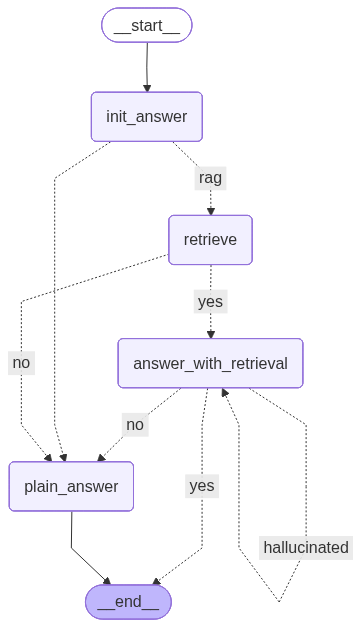

In [3]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

완성된 그래프로 챗봇을 사용해봅시다. `self_rag_answer` 대신 `graph.invoke()`로 실행합니다.

In [ ]:
while True:
    question = input("질문을 입력해주세요 (종료를 원하시면 '종료'를 입력해주세요.): ")
    if question == "종료":
        break
    print("Assistant:", graph.invoke({"question": question})["generation"])